In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from fcmeans import FCM
from kneed import KneeLocator

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


In [2]:
# Selecting k number of clusters
kmeans_kwargs = {
    "init": "random",
    "n_init": 10,
    "max_iter": 300,
    "random_state": 42,
}

# funtion to identify optimum k 
def OptimumK(scaled_vals, maxK):
    # by default test from 2 up to 30 centers
    # A list holds the SSE values for each k
    sse = []
    # A list holds the silhouette coefficients for each k
    silhouette_coefficients = []
    
    for k in range(2, maxK):
        kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
        kmeans.fit(scaled_vals)
        # elbow method
        sse.append(kmeans.inertia_)
        # silhouette    method
        score = silhouette_score(scaled_vals, kmeans.labels_)
        silhouette_coefficients.append(score)    

    # optimum elbow
    kl = KneeLocator( range(2, maxK), sse, curve="convex", direction="decreasing")
    return sse, silhouette_coefficients, kl.elbow

def OptimumK_short(scaled_vals, maxK):
    # by default test from 2 up to 30 centers
    # A list holds the SSE values for each k
    # return only elbow value
    sse = []
    # A list holds the silhouette coefficients for each k
    silhouette_coefficients = []
    
    for k in range(2, maxK):
        kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
        kmeans.fit(scaled_vals)
        # elbow method
        sse.append(kmeans.inertia_)
        # silhouette    method
        #score = silhouette_score(scaled_vals, kmeans.labels_)
        #silhouette_coefficients.append(score)    

    # optimum elbow
    kl = KneeLocator( range(2, maxK), sse, curve="convex", direction="decreasing")
    return kl.elbow
        


In [3]:
def PlotQC_kmeans(sse_vals, elbow, silhouette_vals, ktested):
    f, axes = plt.subplots(1, 2, figsize=(15,5))
    
    axes[0].plot(range(2, ktested), sse_vals, lw=2)
    axes[0].set_xticks(range(2, ktested, 2))
    axes[0].set(xlabel="Number of Clusters", ylabel="SSE")    
    axes[0].axvline(x=elbow, linestyle='--', lw=2)
    #
    axes[1].plot(range(2, ktested), silhouette_vals, lw=2)
    axes[1].set_xticks(range(2, ktested, 2))
    axes[1].set(xlabel="Number of Clusters", ylabel="Silhouette Coefficient")
    #plt.savefig('images/basic-clustering-output.jpg')
    plt.show()



In [4]:
alldf = pd.read_csv('Tsne_Files/tsne_All.txt', sep="\t")
GrCedf = pd.read_csv('Tsne_Files/tsne_CEN_GRN.txt', sep="\t")

alldf = alldf.set_index('gid')
GrCedf = GrCedf.set_index('gid')
GrCedf

,V1,V2
gid,,
ENSRNA049441657,-16.771763,10.789674
ENSRNA049453693,-16.424830,7.252140
ENSRNA049453717,-16.702009,32.920207
ENSRNA049453841,-18.628522,9.884413
ENSRNA049454125,-16.592980,10.829697
...,...,...
Zm00001d054106,11.685937,-25.579745
Zm00001d054107,1.646405,1.196786
Zm00001d054110,-24.584746,-14.435854


In [5]:
# df as numpy arrays
sf_all = alldf.to_numpy()
sf_GrCe = GrCedf.to_numpy()


In [6]:
# First round testing
GrCe_r1_opts = OptimumK(sf_GrCe, 30)

In [7]:
# First round testing
all_r1_opts = OptimumK(sf_all, 30)

In [8]:
print(all_r1_opts[2])
print(GrCe_r1_opts[2])

8
7


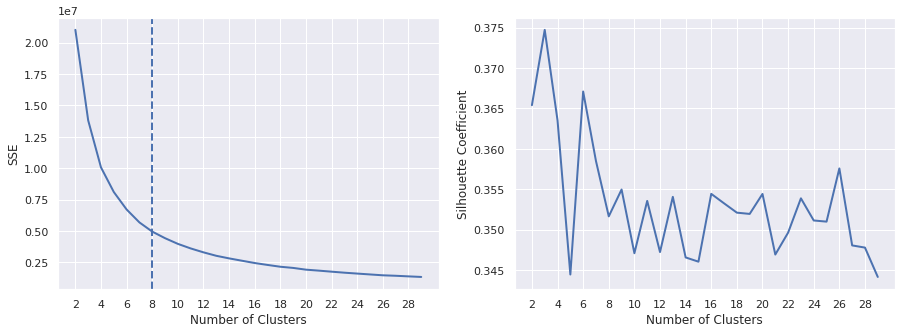

In [9]:
PlotQC_kmeans(all_r1_opts[0], all_r1_opts[2], all_r1_opts[1], 30)

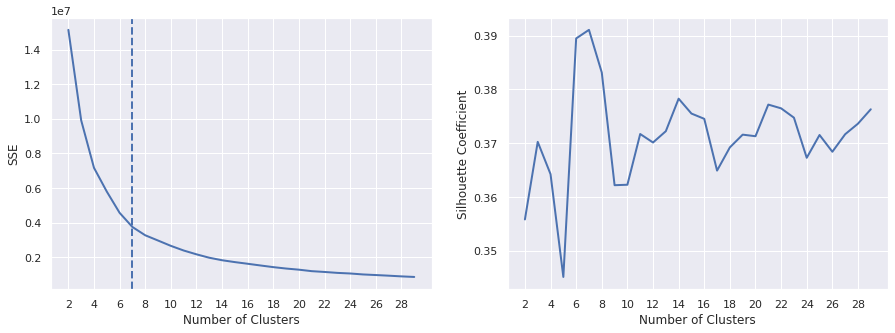

In [10]:
PlotQC_kmeans(GrCe_r1_opts[0], GrCe_r1_opts[2], GrCe_r1_opts[1], 30)

In [ ]:
# after first round: 
## All layers     k=8
## GRN_CEN layers k=7

In [11]:
# all layers
R1_all_kmeans = KMeans(n_clusters=8, **kmeans_kwargs)
R1_all_kmeans.fit(sf_all)


KMeans(init='random', random_state=42)

In [12]:
# Grn_Cen layers
R1_GrCen_kmeans = KMeans(n_clusters=7, **kmeans_kwargs)
R1_GrCen_kmeans.fit(sf_GrCe)



KMeans(init='random', n_clusters=7, random_state=42)

In [13]:
print(R1_all_kmeans.inertia_)
print(R1_GrCen_kmeans.inertia_)


4955974.004407157
3742126.2383105843


In [14]:
R1_all_kmeans.labels_[:10]

array([6, 4, 2, 2, 2, 2, 2, 2, 6, 4], dtype=int32)

In [15]:
# make df with labes and gene ids
R1_all   = pd.DataFrame({'GeneID':alldf.index, 'Module':R1_all_kmeans.labels_, 'Round':1}) 
R1_GrCen = pd.DataFrame({'GeneID':GrCedf.index, 'Module':R1_GrCen_kmeans.labels_, 'Round':1}) 

# alldf
# GrCedf

# Count Freq
#y = np.bincount(R1_all_kmeans.labels_)
#ii = np.nonzero(y)[0]
#np.vstack((ii,y[ii]))
R1_all

,GeneID,Module,Round
0,ENSRNA049441657,6,1
1,ENSRNA049453693,4,1
2,ENSRNA049453717,2,1
3,ENSRNA049453841,2,1
4,ENSRNA049454125,2,1
...,...,...,...
36326,Zm00001d054106,3,1
36327,Zm00001d054107,1,1
36328,Zm00001d054110,4,1
36329,Zm00001d054111,4,1


In [27]:
R1_all.to_csv("Cluster_Round1_all_tsne.txt", sep='\t',index=False)
R1_GrCen.to_csv("Cluster_Round1_GRN_CEN_tsne.txt", sep='\t', index=False)

In [77]:
#R1_all   = pd.read_csv('Cluster_Round1_all_tsne.txt', sep="\t")#.iloc[:,1:4]
#R1_GrCen = pd.read_csv('Cluster_Round1_GRN_CEN_tsne.txt', sep="\t")#.iloc[:,1:4]


In [17]:
R1_GrCen

,GeneID,Module,Round
0,ENSRNA049441657,3,1
1,ENSRNA049453693,3,1
2,ENSRNA049453717,3,1
3,ENSRNA049453841,3,1
4,ENSRNA049454125,3,1
...,...,...,...
36326,Zm00001d054106,1,1
36327,Zm00001d054107,6,1
36328,Zm00001d054110,0,1
36329,Zm00001d054111,0,1


In [18]:
R1_all = R1_all.set_index('GeneID')
R1_GrCen = R1_GrCen.set_index('GeneID')


R1_all["Module"] = pd.to_numeric(R1_all["Module"])
R1_GrCen["Module"] = pd.to_numeric(R1_GrCen["Module"])
R1_GrCen

,Module,Round
GeneID,,
ENSRNA049441657,3,1
ENSRNA049453693,3,1
ENSRNA049453717,3,1
ENSRNA049453841,3,1
ENSRNA049454125,3,1
...,...,...
Zm00001d054106,1,1
Zm00001d054107,6,1
Zm00001d054110,0,1


In [19]:
All_Modules_1  = R1_all.Module.unique()
GrCe_Modules_1 = R1_GrCen.Module.unique()
print(All_Modules_1)
print(GrCe_Modules_1)

[6 4 2 3 1 7 5 0]
[3 0 4 6 1 5 2]


In [20]:
# optimum numbed of clusters using all layers

All_elbows_R1 = []

for M in All_Modules_1:
        # Genes in module M
        #
        tem = alldf.loc[R1_all[R1_all["Module"] == M].index]
        tem = tem.to_numpy()
        #
        sub_elbows = OptimumK_short(tem, 20)
        
        All_elbows_R1.append(sub_elbows)
        size = tem.shape
        print("Module {}: genes {} and Obt K: {}".format(M, size[0], sub_elbows))
        

# sse.append(kmeans.inertia_)
#
All_elbows_R1

Module 6: genes 4837 and Obt K: 5
Module 4: genes 4546 and Obt K: 5
Module 2: genes 4325 and Obt K: 6
Module 3: genes 4367 and Obt K: 6
Module 1: genes 5747 and Obt K: 5
Module 7: genes 3566 and Obt K: 6
Module 5: genes 4615 and Obt K: 6
Module 0: genes 4328 and Obt K: 7


[5, 5, 6, 6, 5, 6, 6, 7]

In [21]:
# optimum numbed of clusters 
GrCe_elbows_R1 = []


for M in GrCe_Modules_1:
        # Genes in module M
        #print(M)
        tem = GrCedf.loc[R1_GrCen[R1_GrCen["Module"] == M].index] # df with pencapy vales
        tem = tem.to_numpy()
        #print(tem.shape)
        sub_elbows = OptimumK_short(tem, 20)
        #
        GrCe_elbows_R1.append(sub_elbows)
        size = tem.shape
        print("Module {}, genes {} and modules {}".format(M, size[0], sub_elbows))
        
        

#sse.append(kmeans.inertia_)
#
GrCe_elbows_R1

Module 3, genes 5521 and modules 6
Module 0, genes 5236 and modules 7
Module 4, genes 4289 and modules 5
Module 6, genes 6499 and modules 6
Module 1, genes 4983 and modules 5
Module 5, genes 4617 and modules 7
Module 2, genes 5186 and modules 5


[6, 7, 5, 6, 5, 7, 5]

In [22]:
###############################################################
# Second round of kmeans using optimum elbows from Rounds 1
####


# R1_GrCen
#for i in range(0, len(All_Modules_1)):

R2_all = pd.DataFrame([])


for i in range(0, len(All_Modules_1)):
    print([All_Modules_1[i], All_elbows_R1[i]])
    
    M = All_Modules_1[i]
    # Subset initial DF
    tem = alldf.loc[R1_all[R1_all["Module"] == M].index]
    # save genes ids
    # print(tem.shape)
    tem_genes = tem.index
    print('gene index len: {}'.format(len(tem_genes)))
    #
    tem = tem.to_numpy()
    # kmeans 
    R2_all_ks = KMeans(n_clusters=All_elbows_R1[i], **kmeans_kwargs)
    R2_all_ks.fit(tem)
    
    # make module index combining first and second round of clustering
    
    index_modules = [ (str(M)+'_') + str(i) for i in R2_all_ks.labels_]
    print('number of labels: {}'.format(len(index_modules)))    
    #print(index_modules)
    #
    R2_all_ks = pd.DataFrame({'GeneID':tem_genes, 'k':R2_all_ks.labels_, 'Module': index_modules}) 
    R2_all = R2_all.append(R2_all_ks)
    #
R2_all

[6, 5]
gene index len: 4837
number of labels: 4837
[4, 5]
gene index len: 4546
number of labels: 4546
[2, 6]
gene index len: 4325
number of labels: 4325
[3, 6]
gene index len: 4367
number of labels: 4367
[1, 5]
gene index len: 5747
number of labels: 5747
[7, 6]
gene index len: 3566
number of labels: 3566
[5, 6]
gene index len: 4615
number of labels: 4615
[0, 7]
gene index len: 4328
number of labels: 4328


,GeneID,k,Module
0,ENSRNA049441657,3,6_3
1,ENSRNA049454767,3,6_3
2,ENSRNA049455261,0,6_0
3,ENSRNA049455301,0,6_0
4,ENSRNA049455334,0,6_0
...,...,...,...
4323,Zm00001d054000,3,0_3
4324,Zm00001d054015,1,0_1
4325,Zm00001d054043,1,0_1
4326,Zm00001d054044,4,0_4


In [23]:
###############################################################
# Second round of kmeans using optimum elbows from Rounds 1
####


# R1_GrCen
GrCe_Modules_1
GrCe_elbows_R1

R2_GrCe = pd.DataFrame([])


for i in range(0, len(GrCe_Modules_1)):
    print([GrCe_Modules_1[i], GrCe_elbows_R1[i]])
    
    M = GrCe_Modules_1[i]
    # Subset initial DF
    tem = GrCedf.loc[R1_GrCen[R1_GrCen["Module"] == M].index]
    # save genes ids
    # print(tem.shape)
    tem_genes = tem.index
    print('gene index len: {}'.format(len(tem_genes)))
    #
    tem = tem.to_numpy()
    # kmeans 
    R2_GrCe_ks = KMeans(n_clusters=GrCe_elbows_R1[i], **kmeans_kwargs)
    R2_GrCe_ks.fit(tem)
    
    # make module index combining first and second round of clustering    
    index_modules = [ (str(M)+'_') + str(i) for i in R2_GrCe_ks.labels_]
    
    print('number of labels: {}'.format(len(index_modules)))    
    #print(index_modules)
    #
    R2_GrCe_ks = pd.DataFrame({'GeneID':tem_genes, 'k':R2_GrCe_ks.labels_, 'Module': index_modules}) 
    R2_GrCe    = R2_GrCe.append(R2_GrCe_ks)
    #
R2_GrCe

[3, 6]
gene index len: 5521
number of labels: 5521
[0, 7]
gene index len: 5236
number of labels: 5236
[4, 5]
gene index len: 4289
number of labels: 4289
[6, 6]
gene index len: 6499
number of labels: 6499
[1, 5]
gene index len: 4983
number of labels: 4983
[5, 7]
gene index len: 4617
number of labels: 4617
[2, 5]
gene index len: 5186
number of labels: 5186


,GeneID,k,Module
0,ENSRNA049441657,1,3_1
1,ENSRNA049453693,1,3_1
2,ENSRNA049453717,2,3_2
3,ENSRNA049453841,1,3_1
4,ENSRNA049454125,1,3_1
...,...,...,...
5181,Zm00001d054066,4,2_4
5182,Zm00001d054067,0,2_0
5183,Zm00001d054069,0,2_0
5184,Zm00001d054071,0,2_0


In [26]:
#R2_all
# Count Freq
#y = np.bincount(R2_all.Module)
#ii = np.nonzero(y)[0]
#np.vstack((ii,y[ii]))

# R2_all

R2_all.to_csv("Cluster_Round2_all_tsne.txt", sep='\t', index=False)
R2_GrCe.to_csv("Cluster_Round2_GRN_CEN_tsne.txt", sep='\t', index=False)
#



In [68]:
GrCe_Modules_1

array([21,  6,  0, 19, 18, 11,  4, 10,  3, 20, 13, 12,  8, 16, 14, 17, 15,
        7,  1,  9,  2,  5])

In [25]:
R2_all

,GeneID,k,Module
0,ENSRNA049441657,3,6_3
1,ENSRNA049454767,3,6_3
2,ENSRNA049455261,0,6_0
3,ENSRNA049455301,0,6_0
4,ENSRNA049455334,0,6_0
...,...,...,...
4323,Zm00001d054000,3,0_3
4324,Zm00001d054015,1,0_1
4325,Zm00001d054043,1,0_1
4326,Zm00001d054044,4,0_4


['2_1', '2_3', '2_4']